## Authorship

- **Course / code author:** Xinze Li  
- **Tutorial article:** Xinze Li, Fanfan Lin, Juan J. Rodríguez-Andina, Sergio Vazquez, Homer Alan Mantooth, Leopoldo García Franquelo, "Fundamentals of Artificial Intelligences for Power Electronics," *IEEE Transactions on Industrial Electronics*, 2026.

*These learning resources are still under active refinement; notebooks, data, and documentation may change.*

---



#### Data-Driven Performance Modeling for Buck Converters
* Objective 1: Efficiency
* Objective 2: Inductor current ripple
* Algorithm: XGBoost and Random Forest

##### 1 Load buck converter simulation data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data from the CSV file
data = pd.read_csv("sync_buck_performances_cleaned.csv")

# Remove rows with any NaN values
data = data.dropna()

# Calculate the ripple current ratio
data['ripple_ratio'] = (data['ilmax'] - data['ilmin']) / (data['ilmax'] + data['ilmin']) * 2

# Remove outliers using Z-score method
def remove_outliers(df, column):
    z_scores = np.abs((df[column] - df[column].mean()) / df[column].std())
    return df[z_scores < 3]  # Remove points more than 3 standard deviations from mean

# Remove outliers for both output variables
data = remove_outliers(data, 'eff')
data = remove_outliers(data, 'ripple_ratio')

# Basic data analysis
print("\nDataset Overview:")
print(data.info())


Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 228 entries, 2 to 251
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   f             228 non-null    float64
 1   L             228 non-null    float64
 2   C             228 non-null    float64
 3   pin           228 non-null    float64
 4   pout          228 non-null    float64
 5   eff           228 non-null    float64
 6   ilmax         228 non-null    float64
 7   ilmin         228 non-null    float64
 8   vmax          228 non-null    float64
 9   vmin          228 non-null    float64
 10  ripple_ratio  228 non-null    float64
dtypes: float64(11)
memory usage: 21.4 KB
None


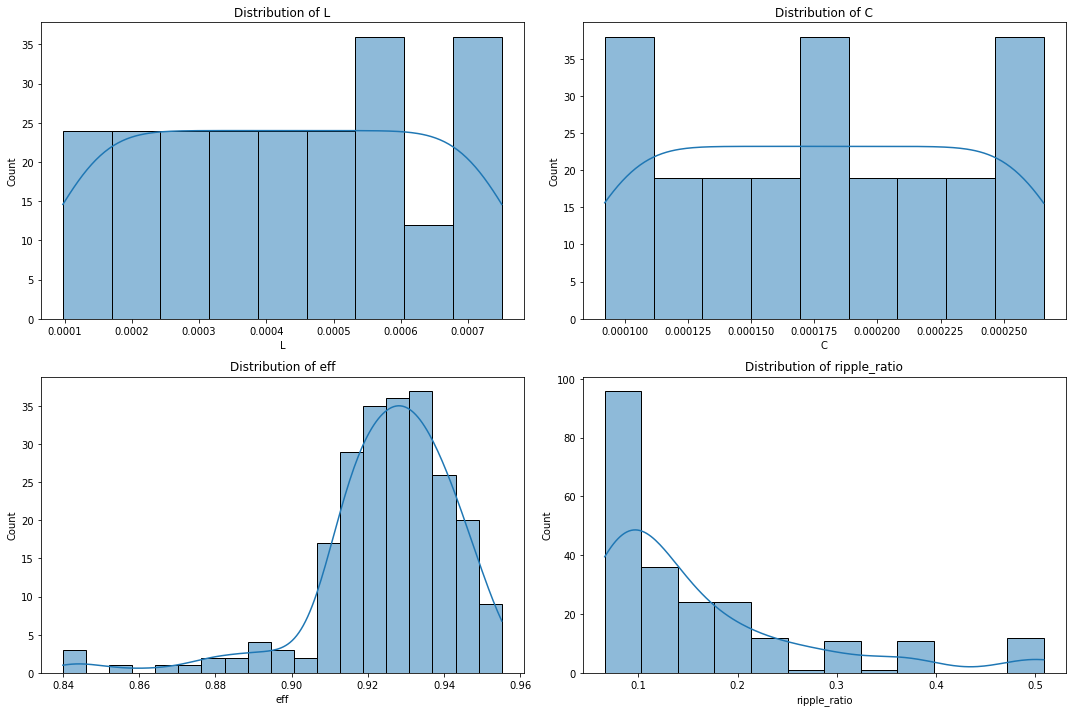


Input-Output Correlation Matrix:
        eff  ripple_ratio
L  0.065383     -0.858565
C  0.341264      0.006756


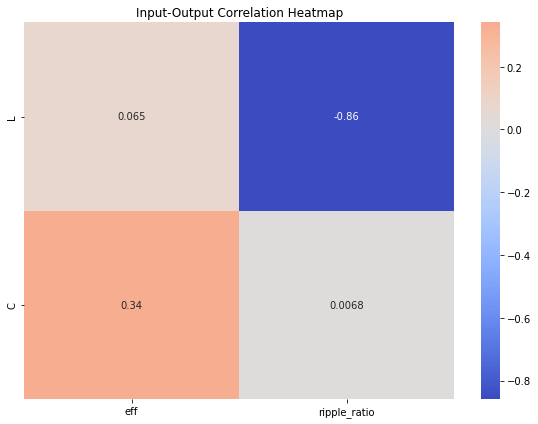

(228, 11)


In [2]:
# Separate inputs and outputs
inputs = ['L', 'C']
outputs = ['eff', 'ripple_ratio']

# Create histograms for all variables
plt.figure(figsize=(15, 10))
for i, var in enumerate(inputs + outputs):
    plt.subplot(2, 2, i+1)
    sns.histplot(data[var], kde=True)
    plt.title(f'Distribution of {var}')
plt.tight_layout()
plt.show()

# Multi-variate correlation analysis between inputs and outputs
correlation_matrix = data[inputs + outputs].corr()
input_output_corr = correlation_matrix.loc[inputs, outputs]

print("\nInput-Output Correlation Matrix:")
print(input_output_corr)

# Create heatmap for input-output correlations
plt.figure(figsize=(8, 6))
sns.heatmap(input_output_corr, annot=True, cmap='coolwarm', center=0)
plt.title('Input-Output Correlation Heatmap')
plt.tight_layout()
plt.show()

print(data.shape)

##### 2 Implement XGBoost and random forest for performance modeling

In [3]:
# Import necessary libraries
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

# Prepare data
X = data[inputs].values
y_eff = data['eff'].values
y_ripple = data['ripple_ratio'].values

# Split data into training, validation and testing sets
X_temp, X_test, y_eff_temp, y_eff_test = train_test_split(X, y_eff, test_size=0.2, random_state=42)
_, _, y_ripple_temp, y_ripple_test = train_test_split(X, y_ripple, test_size=0.2, random_state=42)

X_train, X_val, y_eff_train, y_eff_val = train_test_split(X_temp, y_eff_temp, test_size=0.25, random_state=42)
_, _, y_ripple_train, y_ripple_val = train_test_split(X_temp, y_ripple_temp, test_size=0.25, random_state=42)

# Initialize XGBoost models
eff_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    min_child_weight=1,
    subsample=1,
    colsample_bytree=1,
    random_state=42
)

ripple_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Function to get landscape predictions
def get_landscape_predictions(model, X_test):
    # Create mesh grid
    L_range = np.linspace(X_test[:, 0].min(), X_test[:, 0].max(), 50)
    C_range = np.linspace(X_test[:, 1].min(), X_test[:, 1].max(), 50)
    L_grid, C_grid = np.meshgrid(L_range, C_range)
    
    # Get predictions
    pred_data = np.column_stack((L_grid.flatten(), C_grid.flatten()))
    # Convert numpy array to DMatrix for XGBoost prediction
    pred_dmatrix = xgb.DMatrix(pred_data)
    Z = model.predict(pred_dmatrix).reshape(L_grid.shape)
    
    return L_grid, C_grid, Z

# Lists to store intermediate landscapes
eff_landscapes = []
ripple_landscapes = []
# Initialize with zero arrays for both landscapes
L_range = np.linspace(X_test[:, 0].min(), X_test[:, 0].max(), 50)
C_range = np.linspace(X_test[:, 1].min(), X_test[:, 1].max(), 50)
L_grid, C_grid = np.meshgrid(L_range, C_range)
eff_landscapes.append({
    'iteration': 0,
    'L_grid': L_grid,
    'C_grid': C_grid,
    'Z': np.zeros_like(L_grid)  # Zero array with same shape as Z
})

ripple_landscapes.append({
    'iteration': 0,
    'L_grid': L_grid,
    'C_grid': C_grid,
    'Z': np.zeros_like(L_grid)  # Zero array with same shape as Z
})


# Custom callback to save landscapes
def save_landscape_callback(env, model_name=None):
    if env.iteration % 20 == 19:
        L_grid, C_grid, Z = get_landscape_predictions(env.model, X_test)
        if model_name == 'efficiency':
            eff_landscapes.append({
                'iteration': env.iteration+1,
                'L_grid': L_grid,
                'C_grid': C_grid,
                'Z': Z
            })
        elif model_name == 'ripple':
            ripple_landscapes.append({
                'iteration': env.iteration+1,
                'L_grid': C_grid,
                'C_grid': C_grid,
                'Z': Z
            })

# Train models and track losses
print("\nTraining Efficiency Model:")
eff_results = eff_model.fit(
    X_train, y_eff_train,
    eval_set=[(X_train, y_eff_train), (X_val, y_eff_val), (X_test, y_eff_test)],
    eval_metric='mape',
    early_stopping_rounds=50,
    verbose=100,
    callbacks=[lambda env: save_landscape_callback(env, model_name='efficiency')]
)

print("\nTraining Ripple Ratio Model:")
ripple_results = ripple_model.fit(
    X_train, y_ripple_train,
    eval_set=[(X_train, y_ripple_train), (X_val, y_ripple_val), (X_test, y_ripple_test)],
    eval_metric='mape',
    early_stopping_rounds=50,
    verbose=100,
    callbacks=[lambda env: save_landscape_callback(env, model_name='ripple')]
)

# Make predictions
eff_pred = eff_model.predict(X_test)
ripple_pred = ripple_model.predict(X_test)

# Calculate metrics
eff_mape = mean_absolute_percentage_error(y_eff_test, eff_pred)
eff_r2 = r2_score(y_eff_test, eff_pred)
ripple_mape = mean_absolute_percentage_error(y_ripple_test, ripple_pred)
ripple_r2 = r2_score(y_ripple_test, ripple_pred)

print("\nEfficiency Model Performance:")
print(f"Mean Absolute Percentage Error: {eff_mape:.6f}")
print(f"R² Score: {eff_r2:.6f}")

print("\nRipple Ratio Model Performance:")
print(f"Mean Absolute Percentage Error: {ripple_mape:.6f}")
print(f"R² Score: {ripple_r2:.6f}")


d:\Anaconda\lib\site-packages\xgboost\compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index



Training Efficiency Model:
Multiple eval metrics have been passed: 'validation_2-mape' will be used for early stopping.
Will train until validation_2-mape hasn't improved in 50 rounds.
0	validation_0-mape:0.45432	validation_1-mape:0.45370	validation_2-mape:0.45778
100	validation_0-mape:0.16743	validation_1-mape:0.16655	validation_2-mape:0.17235
200	validation_0-mape:0.06220	validation_1-mape:0.06145	validation_2-mape:0.06602
300	validation_0-mape:0.02351	validation_1-mape:0.02265	validation_2-mape:0.02525


d:\Anaconda\lib\site-packages\xgboost\training.py:17: UserWarning: Old style callback is deprecated.  See: https://xgboost.readthedocs.io/en/latest/python/callbacks.html
  warnings.warn(f'Old style callback is deprecated.  See: {link}', UserWarning)


400	validation_0-mape:0.00903	validation_1-mape:0.00856	validation_2-mape:0.00970
500	validation_0-mape:0.00354	validation_1-mape:0.00384	validation_2-mape:0.00396
600	validation_0-mape:0.00155	validation_1-mape:0.00239	validation_2-mape:0.00208
700	validation_0-mape:0.00090	validation_1-mape:0.00206	validation_2-mape:0.00163
800	validation_0-mape:0.00072	validation_1-mape:0.00203	validation_2-mape:0.00150
Stopping. Best iteration:
[825]	validation_0-mape:0.00071	validation_1-mape:0.00203	validation_2-mape:0.00150

Training Ripple Ratio Model:
Multiple eval metrics have been passed: 'validation_2-mape' will be used for early stopping.
Will train until validation_2-mape hasn't improved in 50 rounds.
0	validation_0-mape:3.34960	validation_1-mape:2.72446	validation_2-mape:3.36471
100	validation_0-mape:1.36423	validation_1-mape:1.07510	validation_2-mape:1.34846
200	validation_0-mape:0.58095	validation_1-mape:0.45103	validation_2-mape:0.56292
300	validation_0-mape:0.27839	validation_1-mape:

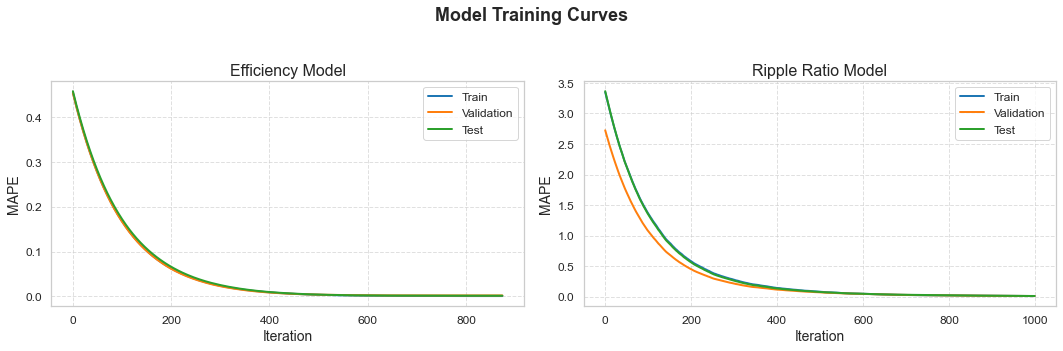

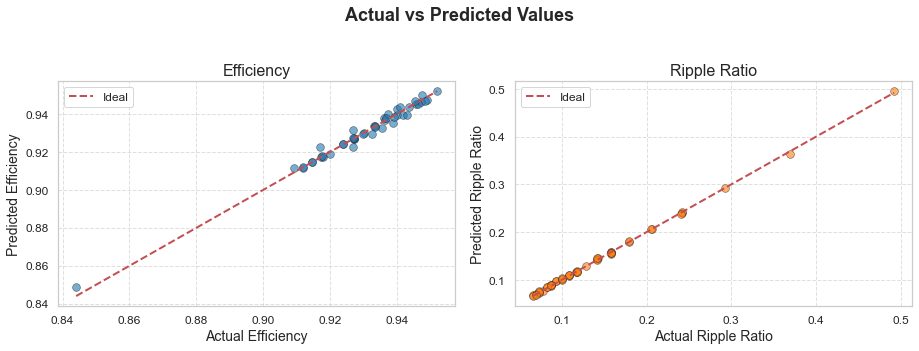


Saved 44 efficiency landscapes at iterations:
   [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340, 360, 380, 400, 420, 440, 460, 480, 500, 520, 540, 560, 580, 600, 620, 640, 660, 680, 700, 720, 740, 760, 780, 800, 820, 840, 860]
Saved 51 ripple ratio landscapes at iterations:
   [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340, 360, 380, 400, 420, 440, 460, 480, 500, 520, 540, 560, 580, 600, 620, 640, 660, 680, 700, 720, 740, 760, 780, 800, 820, 840, 860, 880, 900, 920, 940, 960, 980, 1000]


In [4]:
import seaborn as sns

# Set global style for professional appearance
sns.set(style="whitegrid", font_scale=1.2)
plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.titlesize": 18
})

# Plot training curves with enhanced styling
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Model Training Curves", fontsize=18, fontweight='bold')

# Efficiency model training curves
ax = axes[0]
ax.plot(eff_results.evals_result()['validation_0']['mape'], label='Train', color='#1f77b4', linewidth=2)
ax.plot(eff_results.evals_result()['validation_1']['mape'], label='Validation', color='#ff7f0e', linewidth=2)
ax.plot(eff_results.evals_result()['validation_2']['mape'], label='Test', color='#2ca02c', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('MAPE')
ax.set_title('Efficiency Model')
ax.legend(frameon=True, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.6)

# Ripple model training curves
ax = axes[1]
ax.plot(ripple_results.evals_result()['validation_0']['mape'], label='Train', color='#1f77b4', linewidth=2)
ax.plot(ripple_results.evals_result()['validation_1']['mape'], label='Validation', color='#ff7f0e', linewidth=2)
ax.plot(ripple_results.evals_result()['validation_2']['mape'], label='Test', color='#2ca02c', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('MAPE')
ax.set_title('Ripple Ratio Model')
ax.legend(frameon=True, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Create prediction vs actual plots with professional styling
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Actual vs Predicted Values", fontsize=18, fontweight='bold')

# Efficiency: Actual vs Predicted
ax = axes[0]
sns.scatterplot(x=y_eff_test, y=eff_pred, ax=ax, color='#1f77b4', alpha=0.6, edgecolor='k', s=60)
ax.plot([y_eff_test.min(), y_eff_test.max()],
        [y_eff_test.min(), y_eff_test.max()],
        'r--', lw=2, label='Ideal')
ax.set_xlabel('Actual Efficiency')
ax.set_ylabel('Predicted Efficiency')
ax.set_title('Efficiency')
ax.legend(frameon=True, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.6)

# Ripple Ratio: Actual vs Predicted
ax = axes[1]
sns.scatterplot(x=y_ripple_test, y=ripple_pred, ax=ax, color='#ff7f0e', alpha=0.6, edgecolor='k', s=60)
ax.plot([y_ripple_test.min(), y_ripple_test.max()],
        [y_ripple_test.min(), y_ripple_test.max()],
        'r--', lw=2, label='Ideal')
ax.set_xlabel('Actual Ripple Ratio')
ax.set_ylabel('Predicted Ripple Ratio')
ax.set_title('Ripple Ratio')
ax.legend(frameon=True, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Print information about saved landscapes with clear formatting
print("\n" + "="*60)
print(f"Saved {len(eff_landscapes)} efficiency landscapes at iterations:")
print("  ", [l['iteration'] for l in eff_landscapes])
print(f"Saved {len(ripple_landscapes)} ripple ratio landscapes at iterations:")
print("  ", [l['iteration'] for l in ripple_landscapes])
print("="*60)

#### 3 Implement MHA to Optimize Buck Converters
* The objective function is evaluated with data-driven models

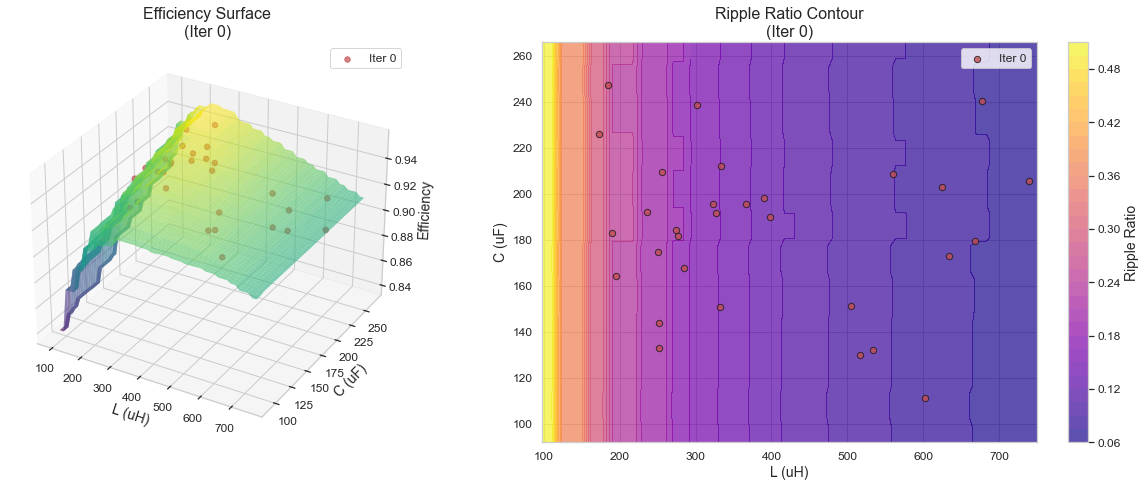

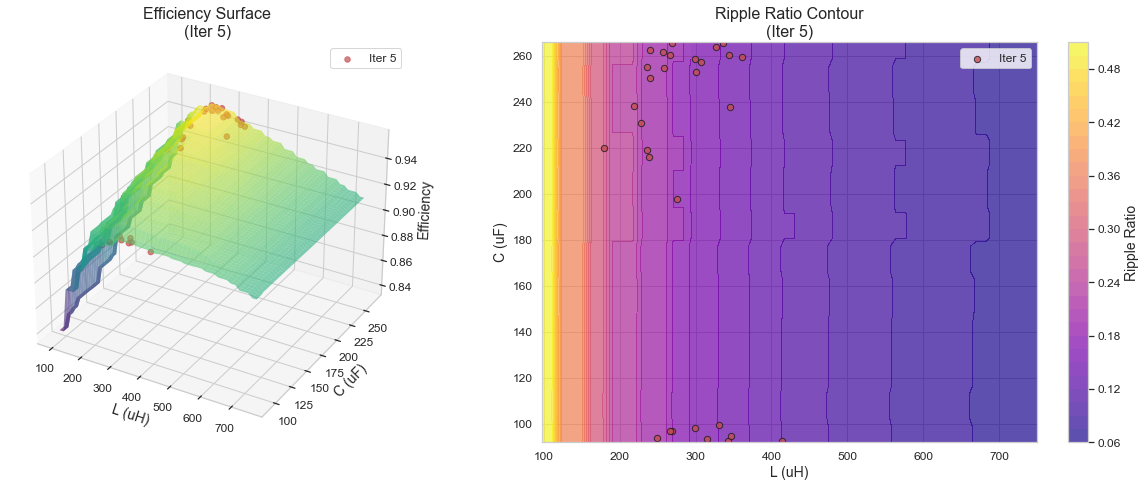

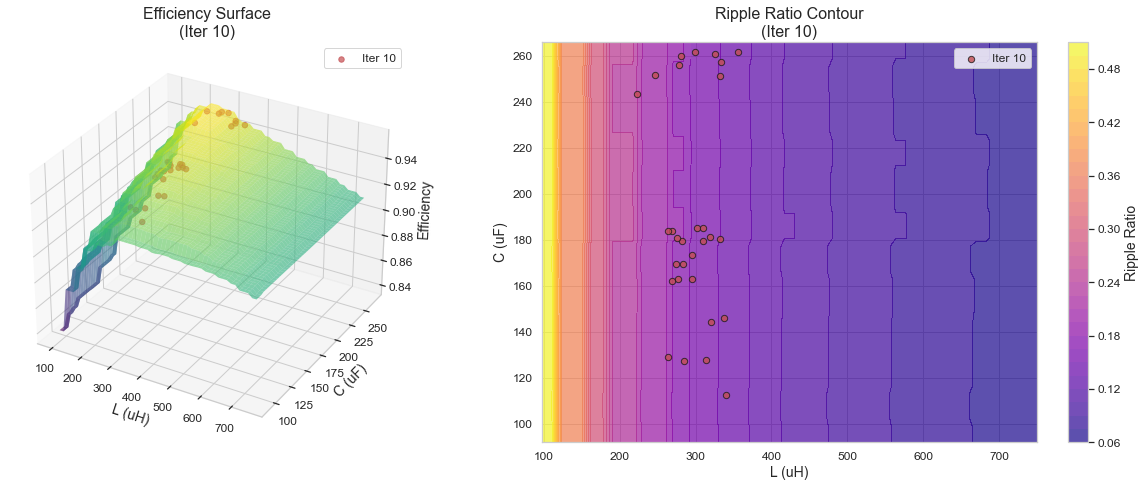

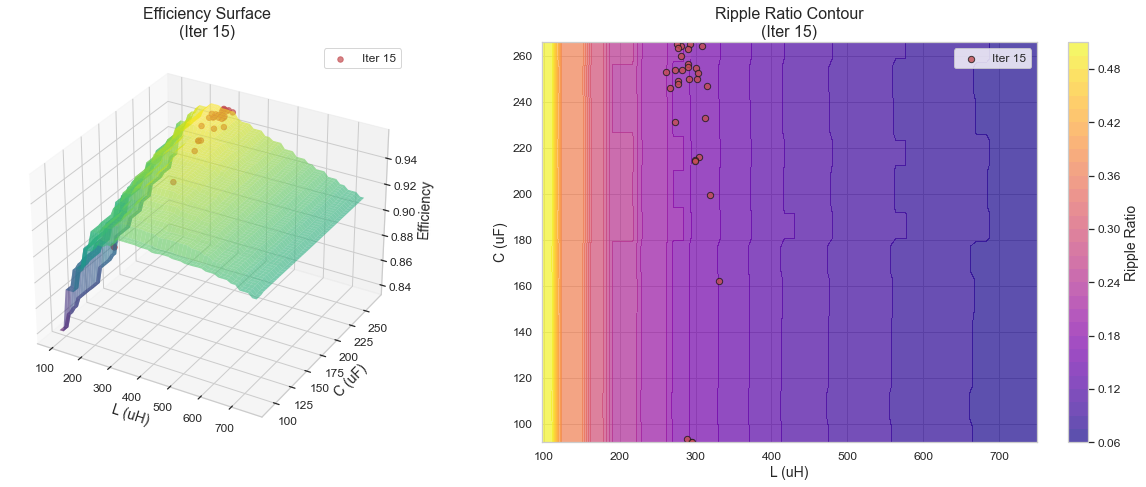

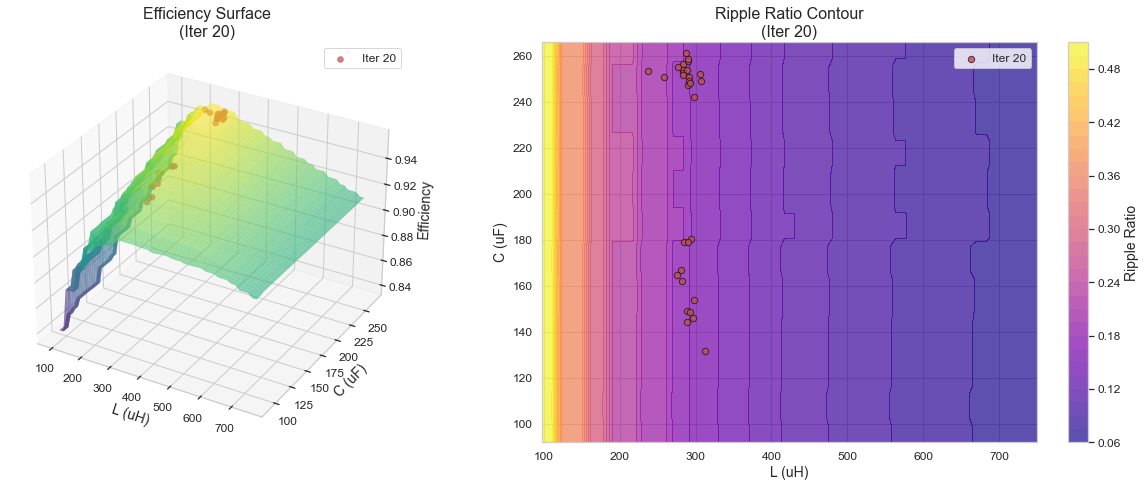

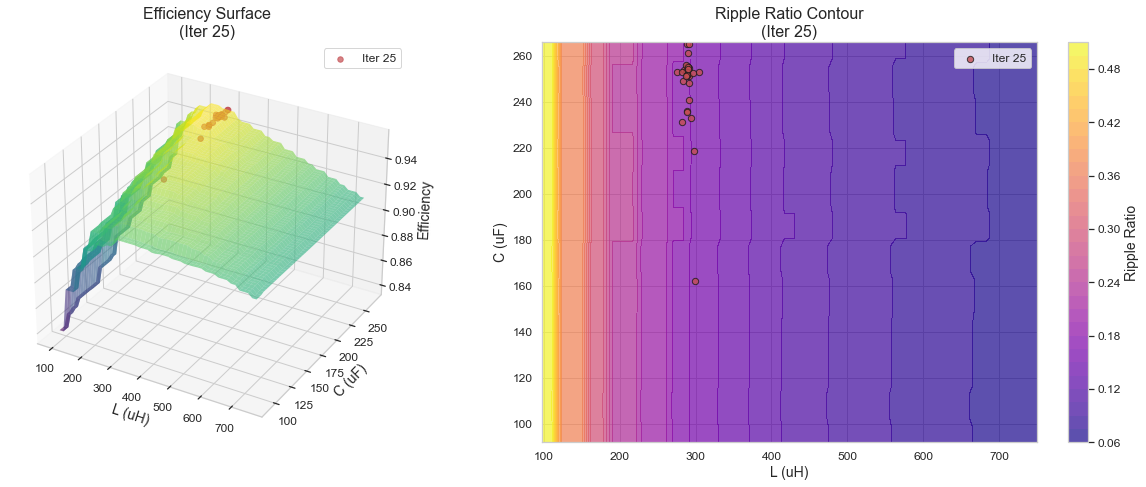

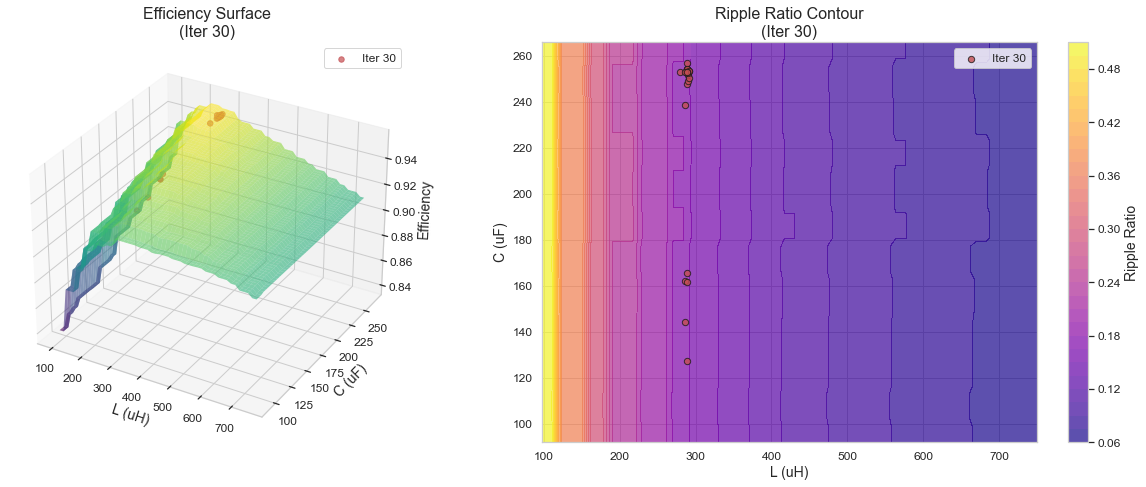

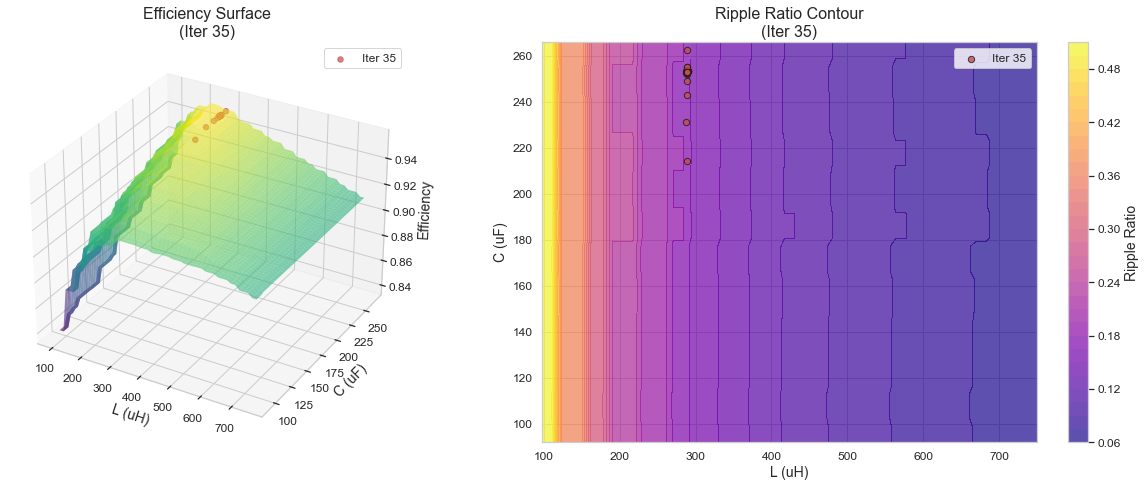

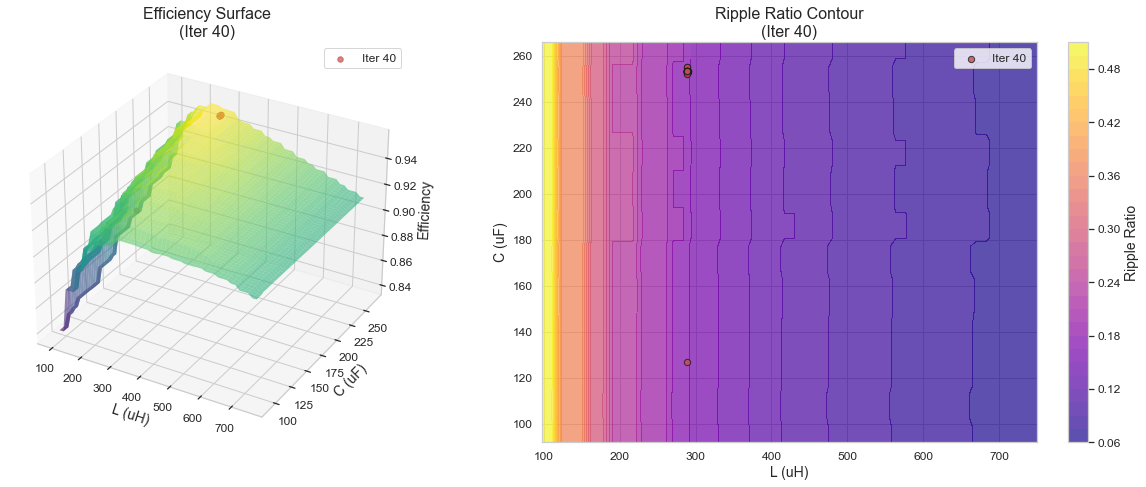

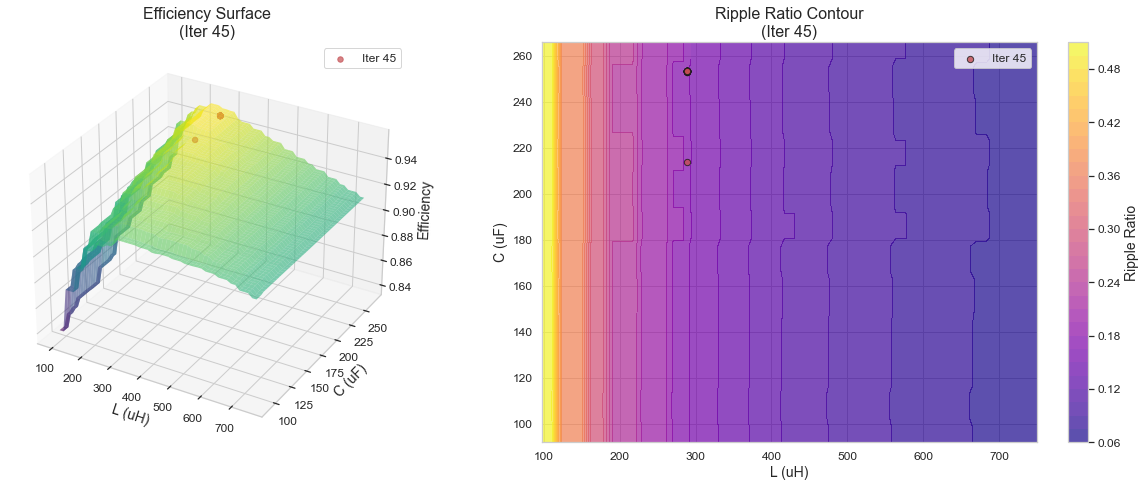

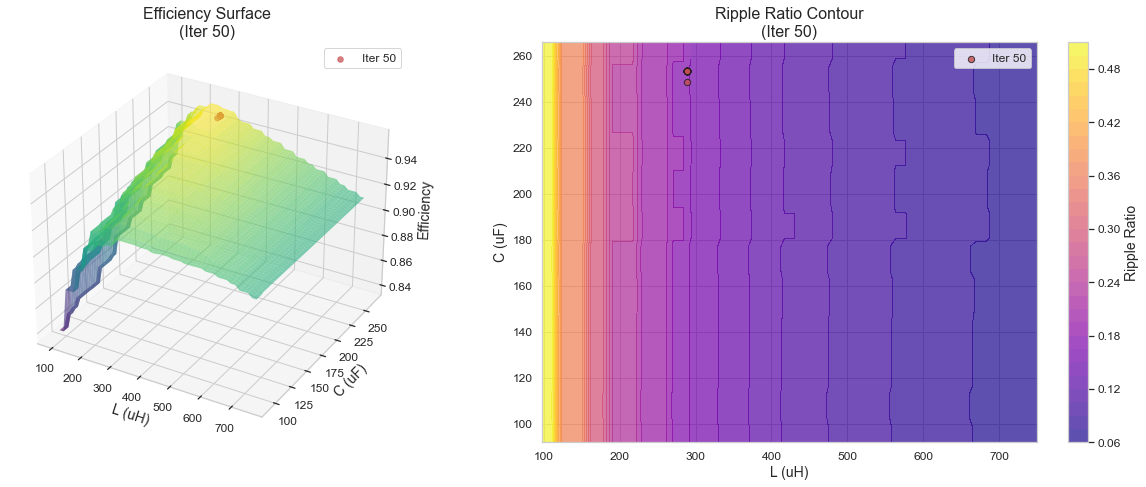

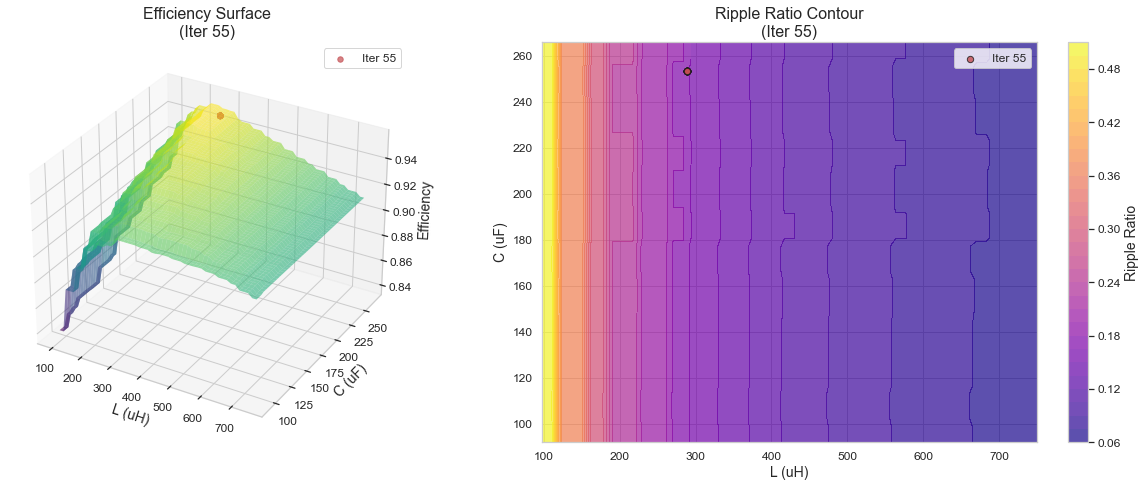

Best L: 289.21 uH, Best C: 253.23 uF, Max Efficiency: 0.9520, Ripple Ratio: 0.1783


In [5]:
import pyswarms as ps
from pyswarms.utils.plotters import plot_cost_history
from mpl_toolkits.mplot3d import Axes3D

# Define bounds for L and C (use the same as in the meshgrid)
L_min, L_max = X_test[:, 0].min(), X_test[:, 0].max()
C_min, C_max = X_test[:, 1].min(), X_test[:, 1].max()
bounds = (np.array([L_min, C_min]), np.array([L_max, C_max]))

# Velocity bounds: 20% of the range for each dimension
vmax = 0.1 * (bounds[1] - bounds[0])
vmin = -vmax
velocity_clamp = (vmin, vmax)

# Objective function: maximize efficiency, penalize if ripple > 15%
def objective(X):
    # X shape: (n_particles, 2)
    L = X[:, 0].reshape(-1, 1)
    C = X[:, 1].reshape(-1, 1)
    X_input = np.hstack([L, C])
    # Predict efficiency and ripple
    eff_pred = eff_model.predict(X_input)
    ripple_pred = ripple_model.predict(X_input)
    # Penalize if ripple > 0.2 (20%)
    penalty = np.where(ripple_pred > 0.2, 1000 * (ripple_pred - 0.2), 0)
    # We want to maximize efficiency, so minimize negative efficiency + penalty
    return -eff_pred + penalty

# PSO options: c1 and c2 to 2.05, w will be changed from 0.9 to 0.4 during operation
options = {'c1': 2.05, 'c2': 2.05, 'w': 0.9}

n_particles = 30
dimensions = 2
n_iters = 60

optimizer = ps.single.GlobalBestPSO(
    n_particles=n_particles, 
    dimensions=dimensions, 
    options=options, 
    bounds=bounds, 
    velocity_clamp=velocity_clamp,
    init_pos=None
)

# Prepare to record particle positions at intervals
record_every = 5
recorded_positions = []

# We'll change w from 0.9 to 0.4 linearly over the iterations
w_start = 0.9
w_end = 0.1

for i in range(n_iters):
    # Linearly interpolate w
    w = w_start + (w_end - w_start) * (i / (n_iters - 1))
    optimizer.options['w'] = w
    # Perform one step of PSO
    optimizer.optimize(objective, iters=1, verbose=False)
    # Record positions every 'record_every' iterations
    if i % record_every == 0:
        recorded_positions.append(optimizer.swarm.position.copy())

# After all iterations, get the best cost and position
cost = optimizer.swarm.best_cost
pos = optimizer.swarm.best_pos

# Prepare meshgrid for surface plot
L_range = np.linspace(L_min, L_max, 50)
C_range = np.linspace(C_min, C_max, 50)
L_grid, C_grid = np.meshgrid(L_range, C_range)
grid_points = np.column_stack([L_grid.flatten(), C_grid.flatten()])
Z_eff = eff_model.predict(grid_points).reshape(L_grid.shape)
Z_ripple = ripple_model.predict(grid_points).reshape(L_grid.shape)

# Plot surface and particle positions at recorded steps, each in a different figure (Efficiency only)
for i, pos_arr in enumerate(recorded_positions):
    fig = plt.figure(figsize=(18, 7))
    
    # 3D Efficiency Surface + Particle Positions
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.plot_surface(L_grid*1e6, C_grid*1e6, Z_eff, cmap='viridis', alpha=0.6, edgecolor='none')
    ax1.scatter(pos_arr[:, 0]*1e6, pos_arr[:, 1]*1e6, 
                eff_model.predict(pos_arr), 
                label=f'Iter {i*record_every}', alpha=0.7, s=30, color='r')
    ax1.set_xlabel('L (uH)')
    ax1.set_ylabel('C (uF)')
    ax1.set_zlabel('Efficiency')
    ax1.set_title(f'Efficiency Surface\n(Iter {i*record_every})')
    ax1.legend()
    
    # 2D Ripple Ratio Contour + Particle Positions
    ax2 = fig.add_subplot(1, 2, 2)
    contour = ax2.contourf(L_grid*1e6, C_grid*1e6, Z_ripple, levels=30, cmap='plasma', alpha=0.7)
    cbar = plt.colorbar(contour, ax=ax2)
    cbar.set_label('Ripple Ratio')
    ax2.scatter(pos_arr[:, 0]*1e6, pos_arr[:, 1]*1e6, 
                label=f'Iter {i*record_every}', alpha=0.8, s=40, color='r', edgecolor='k')
    ax2.set_xlabel('L (uH)')
    ax2.set_ylabel('C (uF)')
    ax2.set_title(f'Ripple Ratio Contour\n(Iter {i*record_every})')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

best_L_uH = pos[0]*1e6
best_C_uF = pos[1]*1e6
max_efficiency = -cost
best_ripple = ripple_model.predict(pos.reshape(1, -1))[0]
print(f"Best L: {best_L_uH:.2f} uH, Best C: {best_C_uF:.2f} uF, Max Efficiency: {max_efficiency:.4f}, Ripple Ratio: {best_ripple:.4f}")
